# Weather Trend Forecasting

## Advanced Assessment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

### Preprocessing

Parse dates since we know we"ll be doing time-series. Remove index column for redundancy

In [2]:
df = pd.read_csv("GlobalWeatherRepository.csv", parse_dates=["last_updated"], index_col=0)

df.sample(5)

,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
country,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Rwanda,Kigali,-1.9536,30.0606,Africa/Kigali,1758959100,2025-09-27 09:45:00,24.3,75.7,Sunny,3.1,5.0,143,SE,1023.0,30.21,0.00,0.0,61,25,25.3,77.5,10.0,6.0,4.6,3.6,5.8,647.50,62.0,9.620,2.775,44.955,45.51,3,5,05:47 AM,05:54 PM,09:39 AM,10:11 PM,Waxing Crescent,22
Djibouti,Djibouti,11.5950,43.1481,Africa/Djibouti,1742635800,2025-03-22 12:30:00,27.6,81.7,Patchy rain nearby,10.3,16.6,71,ENE,1014.0,29.95,0.02,0.0,70,79,30.2,86.3,10.0,6.0,9.5,11.8,19.0,275.65,82.0,1.665,2.405,30.155,68.45,2,3,06:10 AM,06:18 PM,12:11 AM,11:44 AM,Last Quarter,56
Panama,Panama City,8.9667,-79.5333,America/Panama,1761033600,2025-10-21 03:00:00,23.9,75.0,Patchy rain nearby,2.7,4.3,312,NW,1010.0,29.81,0.02,0.0,93,57,26.3,79.4,10.0,6.0,0.0,4.6,7.3,720.85,54.0,7.850,2.950,3.950,4.35,1,1,06:06 AM,05:59 PM,06:05 AM,06:05 PM,New Moon,0
Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1768461300,2026-01-15 10:15:00,16.3,61.3,Sunny,4.5,7.2,224,SW,1018.0,30.07,0.00,0.0,38,0,16.3,61.3,10.0,6.0,7.1,5.1,8.3,151.85,57.0,3.650,2.050,8.250,19.75,1,1,06:33 AM,05:52 PM,03:40 AM,02:55 PM,Waning Crescent,14
Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1767683700,2026-01-06 14:15:00,15.1,59.2,Overcast,11.9,19.1,20,NNE,1026.0,30.30,0.00,0.0,55,0,15.1,59.2,10.0,6.0,0.6,16.6,26.6,745.85,50.0,19.050,24.050,36.950,37.05,2,4,06:35 AM,05:30 PM,08:34 PM,08:56 AM,Waning Gibbous,93


In [ ]:
df.isnull().sum()

In [ ]:
df = df.drop_duplicates()

### Feature Engineering

In [3]:
df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["day"] = df["last_updated"].dt.day
df["day_of_week"] = df["last_updated"].dt.dayofweek
df["day_of_year"] = df["last_updated"].dt.dayofyear

# Cyclical encoding (To help the model to learn seasons for example)
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

In [5]:
df["last_updated"].dt.date.value_counts()

last_updated
2024-05-16    378
2024-05-18    205
2024-09-16    200
2024-06-29    198
2024-07-05    198
2024-07-09    198
2024-07-16    198
2025-01-29    198
2024-06-16    197
2024-07-11    197
2024-09-18    197
2024-09-22    197
2024-11-29    197
2024-12-11    197
2024-12-15    197
2025-01-15    197
2024-12-02    196
2024-12-04    196
2024-12-18    196
2024-12-24    196
2024-12-29    196
2025-01-11    196
2025-10-02    196
2025-11-08    196
2026-02-10    196
2026-02-14    196
2026-03-10    196
2026-04-14    196
2024-05-20    195
2024-05-21    195
2024-05-22    195
2024-05-23    195
2024-05-24    195
2024-05-25    195
2024-05-26    195
2024-05-27    195
2024-05-28    195
2024-05-29    195
2024-05-30    195
2024-06-01    195
2024-06-02    195
2024-06-03    195
2024-06-04    195
2024-06-05    195
2024-06-07    195
2024-06-08    195
2024-06-09    195
2024-06-10    195
2024-06-11    195
2024-06-12    195
2024-06-13    195
2024-06-14    195
2024-06-15    195
2024-06-20    195
2024-06-23    1

In [6]:
dates_to_drop = pd.to_datetime(["2024-07-21", "2026-01-19"]).date

df = df[~df["last_updated"].dt.date.isin(dates_to_drop)]

### Advanced EDA

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

In [ ]:
df[numeric_cols].describe()

In [ ]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Numeric Feature Correlation")
plt.show()

In [ ]:
df.groupby("month")["temperature_celsius"].mean().plot(title="Monthly Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Anomaly Detection

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

I selected a subset of continuous environmental variables (temperature, wind speed, and particulate matter) that directly influence atmospheric conditions. This ensures the Isolation Forest focuses on meaningful physical deviations rather than noise or redundant signals.

In [ ]:
features = ["temperature_celsius", "wind_mph", "air_quality_PM2.5", "air_quality_PM10"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(contamination=0.03, random_state=42)
df["anomaly_iso"] = iso.fit_predict(X_scaled)

In [ ]:
from scipy.stats import zscore

df["z_temp"] = np.abs(zscore(df["temperature_celsius"].fillna(0)))
df["anomaly_z"] = (df["z_temp"] > 3).astype(int)

In [ ]:
# Add a flag if: Isolation Forest says it"s anomalous or Z-score says it"s extreme
df["anomaly_combined"] = ((df["anomaly_iso"] == -1) | (df["anomaly_z"] == 1)).astype(int)

In [ ]:
df.sample(20)

### Forecasting with Multiple Models

In [ ]:
features = [
    # Target
    "temperature_celsius",
    
    # Wind
    "wind_kph",
    "gust_kph",
    "wind_degree",
    
    # Atmospheric
    "pressure_mb",
    "humidity",
    "cloud",
    
    # Precipitation
    "precip_mm",
    
    # Visibility & UV
    "visibility_km",
    "uv_index",

    # Air Quality
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",

    # Time
    "day_of_week",
    "day_of_year",
    "doy_sin",
    "doy_cos",

    # Georgraphy
    "latitude",
    "longitude"
]

In [ ]:
df_model = df.set_index("last_updated")[features].resample("D").mean().ffill()

def create_lag_features(df, target_col, lags=7):
    df_lag = df.copy()

    for i in range(1, lags + 1):
        df_lag[f"{target_col}_lag_{i}"] = df_lag[target_col].shift(i)

    return df_lag.dropna()

lagged = create_lag_features(df_model, "temperature_celsius", lags=14)

In [ ]:
train_size = int(len(lagged) * 0.8)

train = lagged.iloc[:train_size]
test = lagged.iloc[train_size:]

X_train = train.drop(columns=["temperature_celsius"])
y_train = train["temperature_celsius"]

X_test = test.drop(columns=["temperature_celsius"])
y_test = test["temperature_celsius"]

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)

    return mae

ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
def arima_objective(trial):
    p = trial.suggest_int('p', 0, 3)
    d = trial.suggest_int('d', 0, 2)
    q = trial.suggest_int('q', 0, 3)

    try:
        model = ARIMA(df_model, order=(p,d,q)).fit()
        pred = model.forecast(steps=len(y_test))
        return mean_absolute_error(y_test, pred)
    except:
        return float('inf')

XGBoost

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

In [ ]:
tscv = TimeSeriesSplit(n_splits=3)

def xgb_objective(trial):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "mae",

        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),

        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    maes = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = model.predict(X_val)
        maes.append(mean_absolute_error(y_val, preds))

    return np.mean(maes)

Optuna Optimization

In [ ]:
import optuna

In [ ]:
rf_study = optuna.create_study(direction='minimize')
rf_study.optimize(rf_objective, n_trials=30)

print("Best RF params:", rf_study.best_params)

best_rf_model = RandomForestRegressor(**rf_study.best_params, random_state=42)
best_rf_model.fit(X_train, y_train)

rf_pred = best_rf_model.predict(X_test)

print("Best RF MAE:", mean_absolute_error(y_test, rf_pred))

In [ ]:
arima_study = optuna.create_study(direction='minimize')
arima_study.optimize(arima_objective, n_trials=30)

print("Best ARIMA params:", arima_study.best_params)

best_arima_model = ARIMA(df_model["temperature_celsius"], order=(
    arima_study.best_params['p'],
    arima_study.best_params['d'],
    arima_study.best_params['q']
)).fit()

arima_pred = best_arima_model.forecast(steps=len(y_test))

print("Best ARIMA MAE:", mean_absolute_error(y_test, arima_pred))

In [ ]:
xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=30)

print("Best XGB params:", xgb_study.best_params)

best_xgb_model = XGBRegressor(**xgb_study.best_params, random_state=42)

best_xgb_model.fit(X_train, y_train)

xgb_pred = best_xgb_model.predict(X_test)

print("Best XGBoost MAE:", mean_absolute_error(y_test, xgb_pred))

Ensemble Model

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
meta_X = pd.DataFrame({
    'rf': rf_pred,
    'arima': arima_pred[:len(rf_pred)],
    'xgboost': xgb_pred[:len(rf_pred)]
})

meta_model = LinearRegression()
meta_model.fit(meta_X, y_test[:len(meta_X)])

stacked_pred = meta_model.predict(meta_X)

print("Stacked MAE:", mean_absolute_error(y_test[:len(stacked_pred)], stacked_pred))

### Climate Analysis

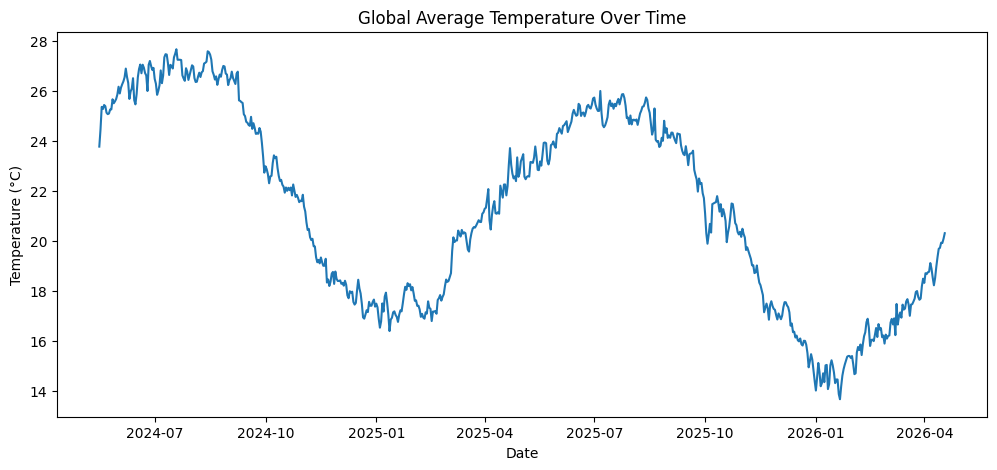

In [7]:
df_temperature = df.set_index("last_updated").resample("D")["temperature_celsius"].mean().ffill()

plt.figure(figsize=(12,5))
plt.plot(df_temperature)
plt.title("Global Average Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

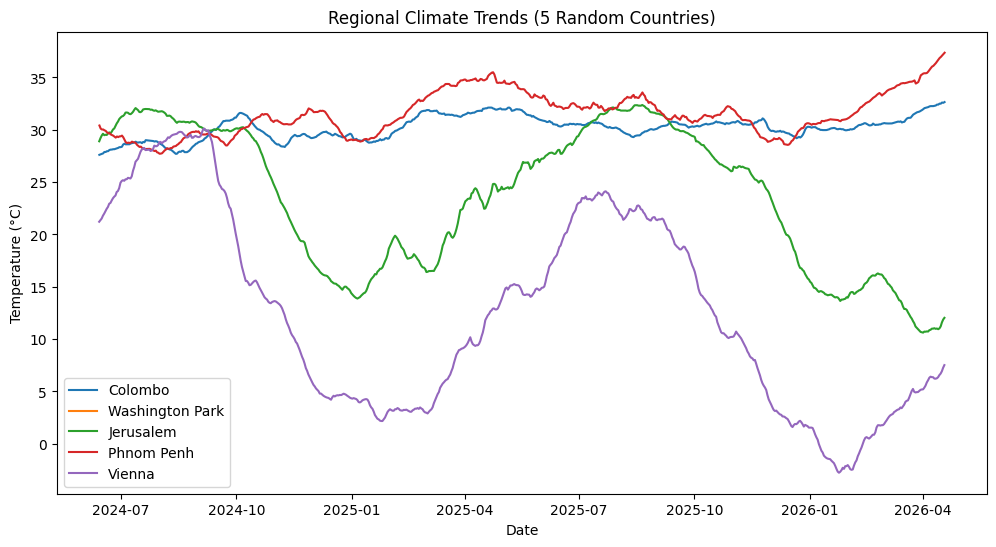

In [ ]:
np.random.seed(42)

countries = df["location_name"].dropna().unique()
sampled = np.random.choice(countries, size=5, replace=False)

plt.figure(figsize=(12,6))

for location in sampled:
    subset = df[df["location_name"] == location]
    
    trend = (
        subset
        .set_index("last_updated")["temperature_celsius"]
        .rolling(window=30)
        .mean()
    )
    
    plt.plot(trend, label=location)

plt.title("Regional Climate Trends (5 Random Countries)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

### Environmental Impact

In [ ]:
sns.scatterplot(
    data=df,
    x='temperature_celsius',
    y='air_quality_PM2.5'
)
plt.title("Temperature vs Air Pollution")
plt.show()

print(df[['temperature_celsius','wind_mph','air_quality_PM2.5']].corr())

### Feature Importance

Random Forest Importance

In [ ]:
features = ['temperature_celsius','wind_mph','humidity','pressure_mb']
target = 'air_quality_PM2.5'

X = df[features].fillna(0)
y = df[target].fillna(0)

best_rf_model.fit(X, y)

importances = pd.Series(best_rf_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', title="Feature Importance")
plt.show()

XGBoost Importance

In [ ]:
from xgboost import plot_importance

In [ ]:
plot_importance(
    best_xgb_model,
    importance_type='gain',
    max_num_features=10,
    height=0.5,
    show_values=False
)

plt.title("Top 10 Feature Importances (XGBoost)", fontsize=14)
plt.show()

### Spatial Analysis

In [ ]:
import plotly.express as px

In [ ]:
fig = px.scatter_geo(
    df,
    lat="latitude",
    lon="longitude",
    size=df["temperature_celsius"].abs(),
    color="temperature_celsius",
    hover_name="location_name",
    title="Global Temperature Patterns",
    color_continuous_scale="RdBu_r"
)

fig.show()

### Geographical Patterns

In [ ]:
continent_temp = df.groupby('country')['temperature_celsius'].mean().sort_values()

print(continent_temp.tail(10))
print(continent_temp.head(10))